In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

data = {
    "Transmission": ["Automatic", "Manual", "Automatic", "Manual", "Automatic"],
    "Color": ["Red", "Blue", "Green", "Red", "Blue"]
}

df = pd.DataFrame(data)

le = LabelEncoder()
df["Transmission"] = le.fit_transform(df["Transmission"])

df = pd.get_dummies(df, columns=["Color"], drop_first=True)

print(df)


   Transmission  Color_Green  Color_Red
0             0        False       True
1             1        False      False
2             0         True      False
3             1        False       True
4             0        False      False


In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

np.random.seed(42)

data = pd.DataFrame({
    "Age": np.random.randint(20, 60, 10),
    "Salary": np.random.randint(20000, 120000, 10)
})

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

standardized_data = pd.DataFrame(
    standard_scaler.fit_transform(data),
    columns=data.columns
)

normalized_data = pd.DataFrame(
    minmax_scaler.fit_transform(data),
    columns=data.columns
)

print("Original Data")
print(data)

print("\nStandardized Data (Mean=0, Std=1)")
print(standardized_data)

print("\nNormalized Data (0 to 1 Range)")
print(normalized_data)


Original Data
   Age  Salary
0   58   64131
1   48   80263
2   34   36023
3   27   61090
4   40   87221
5   58   84820
6   38   20769
7   42   79735
8   30   82955
9   30   84925

Standardized Data (Mean=0, Std=1)
        Age    Salary
0  1.651752 -0.186070
1  0.707894  0.552859
2 -0.613508 -1.473560
3 -1.274209 -0.325363
4 -0.047193  0.871571
5  1.651752  0.761592
6 -0.235965 -2.172271
7  0.141579  0.528673
8 -0.991051  0.676166
9 -0.991051  0.766402

Normalized Data (0 to 1 Range)
        Age    Salary
0  1.000000  0.652531
1  0.677419  0.895293
2  0.225806  0.229549
3  0.000000  0.606769
4  0.419355  1.000000
5  1.000000  0.963869
6  0.354839  0.000000
7  0.483871  0.887347
8  0.096774  0.935803
9  0.096774  0.965449


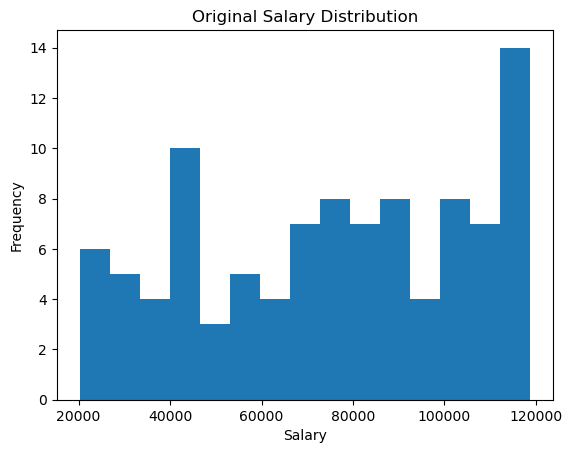

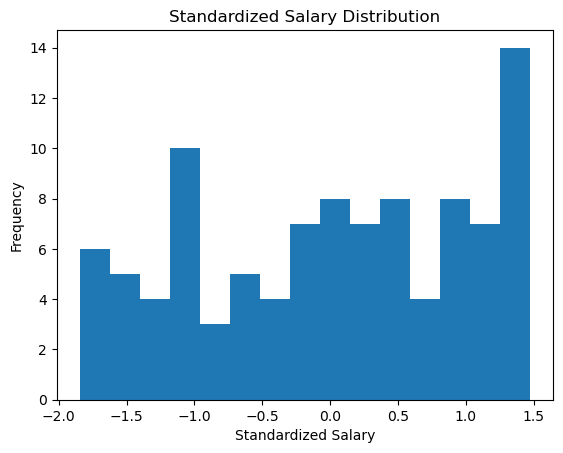

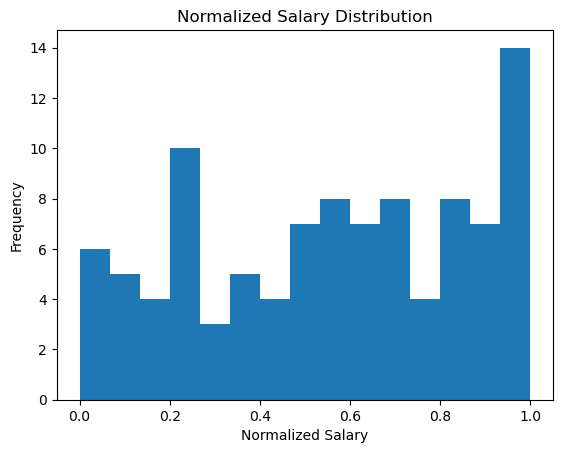

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

np.random.seed(42)

data = pd.DataFrame({
    "Age": np.random.randint(20, 60, 100),
    "Salary": np.random.randint(20000, 120000, 100)
})

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

standardized_data = pd.DataFrame(
    standard_scaler.fit_transform(data),
    columns=data.columns
)

normalized_data = pd.DataFrame(
    minmax_scaler.fit_transform(data),
    columns=data.columns
)

plt.figure()
plt.hist(data["Salary"], bins=15)
plt.title("Original Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(standardized_data["Salary"], bins=15)
plt.title("Standardized Salary Distribution")
plt.xlabel("Standardized Salary")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(normalized_data["Salary"], bins=15)
plt.title("Normalized Salary Distribution")
plt.xlabel("Normalized Salary")
plt.ylabel("Frequency")
plt.show()


R² Score (Linear Features Only): -0.0572
R² Score (Polynomial Features): 0.9524


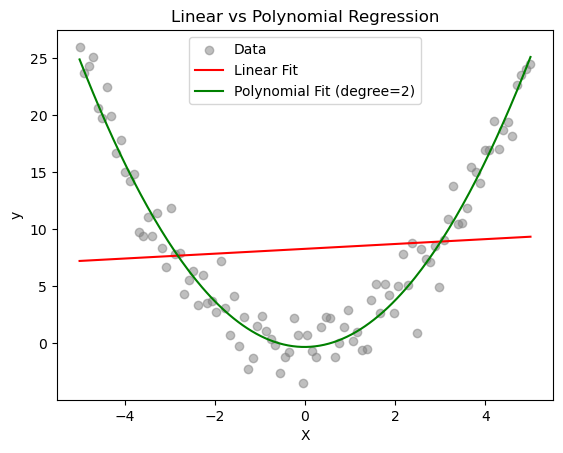

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = np.linspace(-5, 5, 100).reshape(-1, 1)
y = X**2 + np.random.normal(0, 2, size=(100, 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)
r2_linear = r2_score(y_test, y_pred_linear)

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("R² Score (Linear Features Only):", round(r2_linear, 4))
print("R² Score (Polynomial Features):", round(r2_poly, 4))

plt.scatter(X, y, color='gray', alpha=0.5, label="Data")

X_range = np.linspace(-5, 5, 200).reshape(-1, 1)

y_linear_curve = linear_model.predict(X_range)
plt.plot(X_range, y_linear_curve, color='red', label="Linear Fit")

X_range_poly = poly.transform(X_range)
y_poly_curve = poly_model.predict(X_range_poly)
plt.plot(X_range, y_poly_curve, color='green', label="Polynomial Fit (degree=2)")

plt.legend()
plt.title("Linear vs Polynomial Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.show()
